MULTIPLE LINEAR REGRESSION

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [35]:
df=pd.read_csv('economic_index.csv')

In [36]:
df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [37]:
#drop unneccesary columns
df.drop(columns=['Unnamed: 0','year','month'],inplace=True,axis=1)

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   interest_rate      24 non-null     float64
 1   unemployment_rate  24 non-null     float64
 2   index_price        24 non-null     int64  
dtypes: float64(2), int64(1)
memory usage: 708.0 bytes


In [39]:
df.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

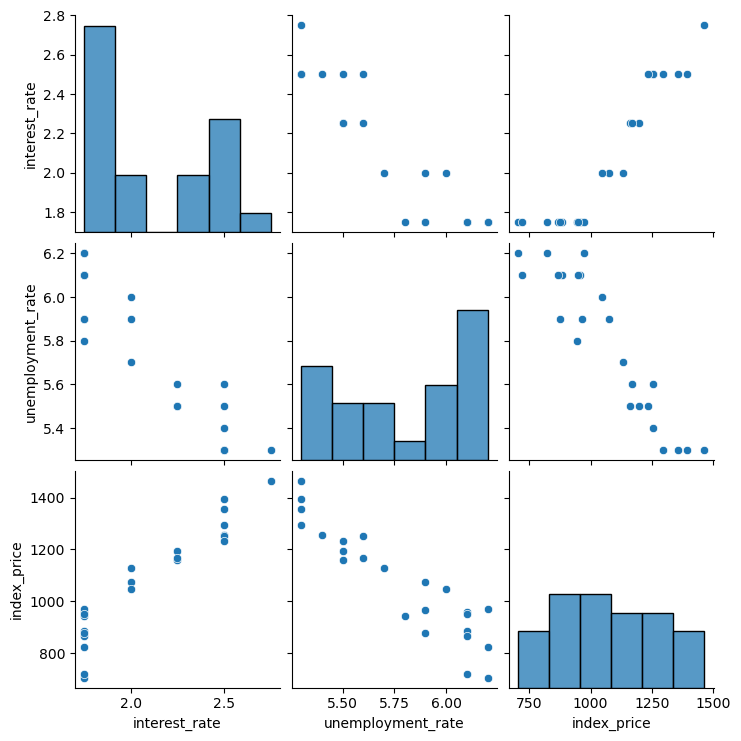

In [40]:
#visualization

import seaborn as sns
sns.pairplot(df)

In [41]:
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


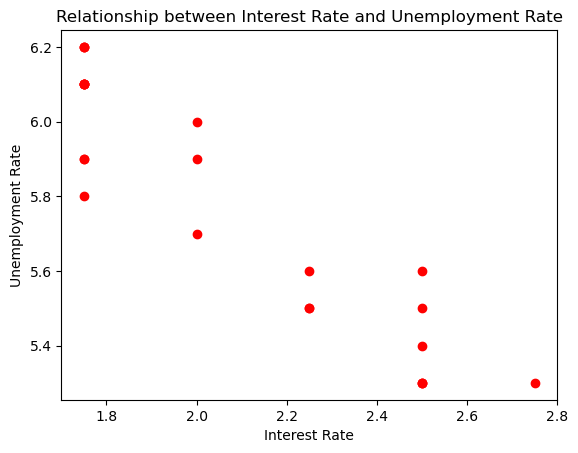

In [42]:
#visualization
plt.scatter(df['interest_rate'],df['unemployment_rate'],color='red')
plt.xlabel('Interest Rate')
plt.ylabel('Unemployment Rate')
plt.title('Relationship between Interest Rate and Unemployment Rate')
plt.show()

In [43]:
X=df[['interest_rate','unemployment_rate']]
#X=df.iloc[:,0:2]

Y=df['index_price']
#Y=df.iloc[:,2]

In [44]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

<Axes: xlabel='interest_rate', ylabel='index_price'>

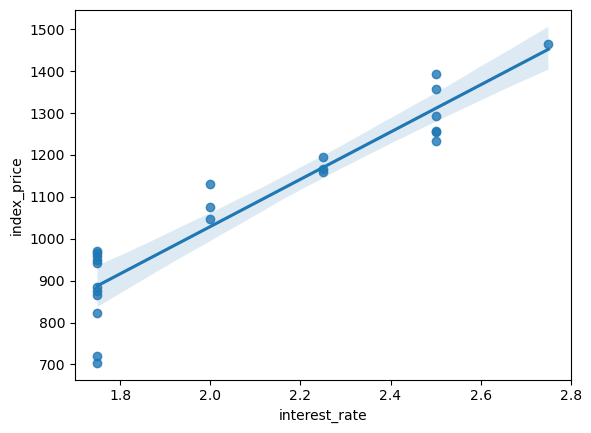

In [45]:
sns.regplot(x='interest_rate',y='index_price',data=df)
#regplot is used to plot the regression line along with the scatter plot of the data points.
#  It helps to visualize the relationship between the independent variable (interest_rate) 
# and the dependent variable (index_price) in this case.

<Axes: xlabel='unemployment_rate', ylabel='index_price'>

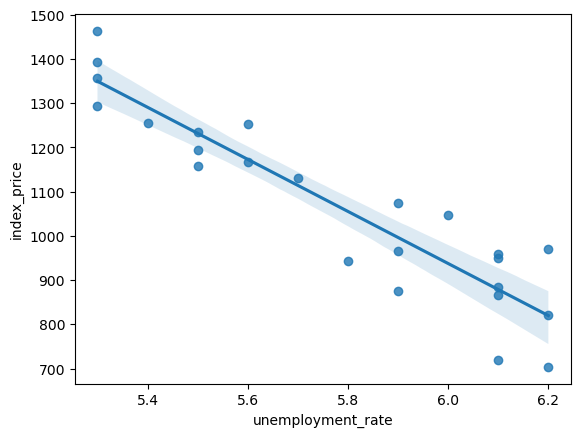

In [46]:
sns.regplot(x='unemployment_rate',y='index_price',data=df)

In [47]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [48]:
X_train

array([[ 0.55339859, -0.53244666],
       [-0.9486833 ,  0.41597395],
       [ 1.30443953, -1.48086727],
       [-0.9486833 ,  1.36439457],
       [ 1.30443953, -0.53244666],
       [ 1.30443953, -1.48086727],
       [-0.19764235,  0.73211416],
       [-0.9486833 ,  1.04825436],
       [ 1.30443953, -1.48086727],
       [ 1.30443953, -1.16472707],
       [-0.9486833 ,  1.36439457],
       [-0.9486833 ,  1.04825436],
       [-0.9486833 ,  0.41597395],
       [-0.9486833 ,  1.04825436],
       [ 0.55339859, -0.84858687],
       [-0.19764235, -0.21630646],
       [-0.9486833 ,  0.09983375],
       [-0.9486833 ,  1.04825436],
       [ 1.30443953, -0.84858687]])

In [49]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()

In [50]:
model.fit(X_train,Y_train)

LinearRegression()

In [51]:
print(model.coef_)
print(model.intercept_)

[  86.63351334 -114.04857249]
1059.4210526315792


In [52]:
from sklearn.model_selection import cross_val_score
#cross_val_score evaluates a model using k-fold cross-validation to get a more reliable estimate of performance
#  than a single train-test split.
#Splits training data into k folds (here cv=5 means 5 folds).
#For each fold: trains on 4 folds, evaluates on the remaining 1 fold.
#Returns an array of k scores (one per fold).


scores=cross_val_score(model,X_train,Y_train,scoring='neg_mean_squared_error',cv=5)

In [53]:
np.mean(scores)

np.float64(-5662.725812144448)

In [54]:
y_pred=model.predict(X_test)

In [55]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

mse=mean_squared_error(Y_test,y_pred)
mae=mean_absolute_error(Y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(Y_test,y_pred)

print('Mean Squared Error:', mse)
print('Mean Absolute Error:', mae)
print('Root Mean Squared Error:', rmse)
print('R2 Score:', r2)

Mean Squared Error: 6957.105303258827
Mean Absolute Error: 71.71878409976621
Root Mean Squared Error: 83.4092638935198
R2 Score: 0.8254940547158577


In [56]:
#display adjusted R2 score
n=len(Y_test) #number of samples in test data
p=X_test.shape[1] #number of features in test data
adjusted_r2=1-(1-r2)*(n-1)/(n-p-1)
print('Adjusted R2 Score:', adjusted_r2)

Adjusted R2 Score: 0.6509881094317154


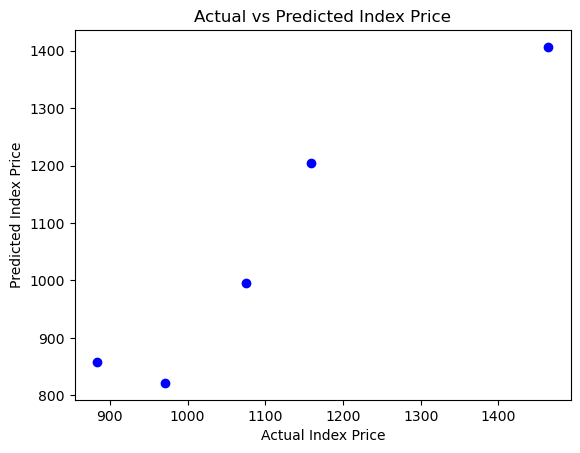

In [58]:
y_pred=model.predict(X_test)
plt.scatter(Y_test,y_pred,color='blue')
plt.xlabel('Actual Index Price')
plt.ylabel('Predicted Index Price')
plt.title('Actual vs Predicted Index Price')
plt.show()

Text(0.5, 1.0, 'Distribution of Residuals')

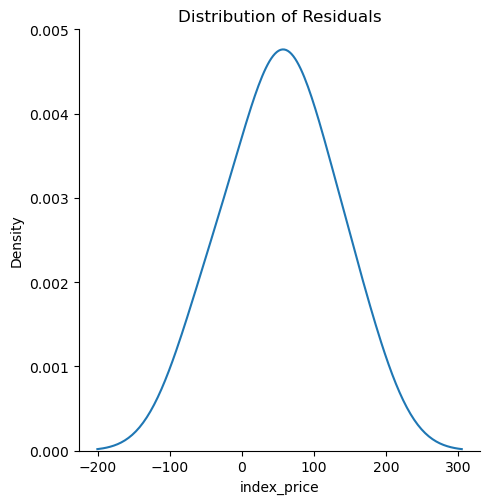

In [60]:
residuals=Y_test-y_pred
sns.displot(residuals, kind='kde')
plt.title('Distribution of Residuals')

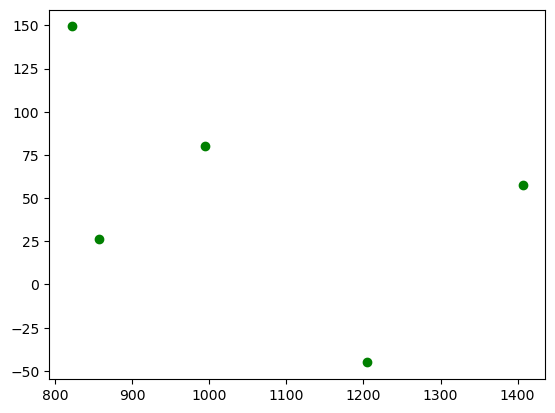

In [61]:
plt.scatter(y_pred,residuals,color='green')

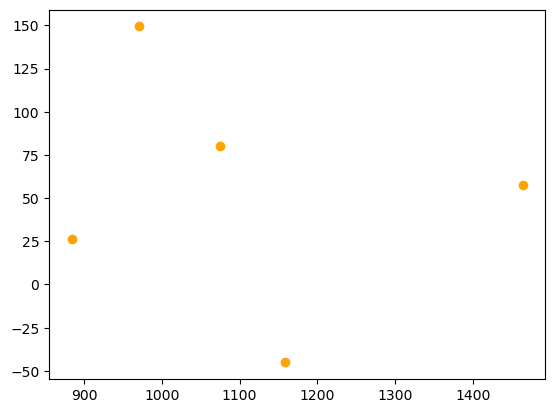

In [62]:
plt.scatter(Y_test,residuals,color='orange')

In [63]:
#ols

import statsmodels.api as sm

model_sm=sm.OLS(Y_train,X_train).fit()
model_sm.summary()


c:\Users\LENOVO\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=19 observations were given.
  return hypotest_fun_in(*args, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.033
Model:                            OLS   Adj. R-squared (uncentered):             -0.081
Method:                 Least Squares   F-statistic:                             0.2916
Date:                Thu, 02 Apr 2026   Prob (F-statistic):                       0.751
Time:                        20:58:50   Log-Likelihood:                         -159.34
No. Observations:                  19   AIC:                                      322.7
Df Residuals:                      17   BIC:                                      324.6
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            86.6335    647.232      0.134      0.895   -1278.906    1452.173
x2          -114.0486    647.232     -0.176      0.862   -1479.588    1251.491
==============================================================================
Omnibus:                        0.676   Durbin-Watson:                   0.007
Prob(Omnibus):                  0.713   Jarque-Bera (JB):                0.526
Skew:                          -0.369   Prob(JB):                        0.769
Kurtosis:                       2.656   Cond. No.                         4.82
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""